In [1]:
import math
import pandas_datareader as web
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
import matplotlib.pyplot as plt

In [2]:
nvda = yf.Ticker('NVDA')
nvda = nvda.history(period='5y')

In [3]:
nvda

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2019-08-26 00:00:00-04:00,4.116487,4.140598,4.074231,4.112510,318208000,0.000,0.0
2019-08-27 00:00:00-04:00,4.150788,4.153523,3.992453,4.021783,290968000,0.000,0.0
2019-08-28 00:00:00-04:00,3.995410,4.064082,3.956098,4.011334,255612000,0.004,0.0
2019-08-29 00:00:00-04:00,4.102896,4.187492,4.099413,4.155147,357976000,0.000,0.0
2019-08-30 00:00:00-04:00,4.201426,4.251188,4.149673,4.167836,290616000,0.000,0.0
...,...,...,...,...,...,...,...
2024-08-19 00:00:00-04:00,124.279999,130.000000,123.419998,130.000000,318333600,0.000,0.0
2024-08-20 00:00:00-04:00,128.399994,129.880005,125.889999,127.250000,300087400,0.000,0.0
2024-08-21 00:00:00-04:00,127.320000,129.350006,126.660004,128.500000,257883600,0.000,0.0


In [4]:
del nvda['Dividends']
del nvda['Stock Splits']

In [5]:
nvda

,Open,High,Low,Close,Volume
Date,,,,,
2019-08-26 00:00:00-04:00,4.116487,4.140598,4.074231,4.112510,318208000
2019-08-27 00:00:00-04:00,4.150788,4.153523,3.992453,4.021783,290968000
2019-08-28 00:00:00-04:00,3.995410,4.064082,3.956098,4.011334,255612000
2019-08-29 00:00:00-04:00,4.102896,4.187492,4.099413,4.155147,357976000
2019-08-30 00:00:00-04:00,4.201426,4.251188,4.149673,4.167836,290616000
...,...,...,...,...,...
2024-08-19 00:00:00-04:00,124.279999,130.000000,123.419998,130.000000,318333600
2024-08-20 00:00:00-04:00,128.399994,129.880005,125.889999,127.250000,300087400
2024-08-21 00:00:00-04:00,127.320000,129.350006,126.660004,128.500000,257883600


In [6]:
nvda.drop(nvda.tail(1).index,inplace=True)

In [7]:
nvda.shape

(1257, 5)

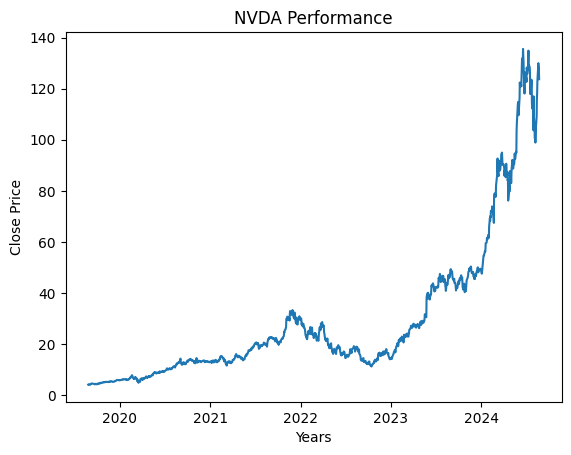

<Figure size 1600x800 with 0 Axes>

In [26]:
plt.plot(nvda.index, nvda['Close'])

# Add title and labels
plt.title('NVDA Performance')
plt.xlabel('Years')
plt.ylabel('Close Price')


# Set the figure size
plt.figure(figsize=(16, 8))

plt.savefig("Line graph of NVDA.png")
plt.show()


In [9]:
#Create new df with only 'Close' column

nvda = nvda.filter(['Close'])

dataset = nvda.values

# Model to train data
training_data_len = math.ceil( len(dataset) * 0.8)

training_data_len

1006

In [10]:
#Scale data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

scaled_data

array([[7.68999668e-04],
       [7.94217168e-05],
       [0.00000000e+00],
       ...,
       [9.36687040e-01],
       [9.46187782e-01],
       [9.10008939e-01]])

In [11]:
#Create new training dataset and scaled training dataset
training_data = scaled_data[0:training_data_len , :]
#Split the data into x_train and y_train
x_train = []
y_train = []

for i in range(60, len(training_data)):
    x_train.append(training_data[i-60:i, 0])
    y_train.append(training_data[i, 0])
    if i<= 61:
        print(x_train)
        print(y_train)
        print()

[array([7.68999668e-04, 7.94217168e-05, 0.00000000e+00, 1.09306158e-03,
       1.18951001e-03, 5.57876492e-04, 1.42590142e-03, 3.50234042e-03,
       3.29620783e-03, 3.64605988e-03, 4.15288162e-03, 4.37036172e-03,
       4.35901059e-03, 3.91838931e-03, 3.59122142e-03, 3.75385944e-03,
       3.54771960e-03, 2.97283452e-03, 2.16911458e-03, 2.57568970e-03,
       2.13884488e-03, 3.21678974e-03, 3.04847253e-03, 1.99323357e-03,
       2.43007476e-03, 2.41683901e-03, 2.23529693e-03, 3.79925311e-03,
       3.92406126e-03, 4.37036172e-03, 3.02765848e-03, 3.68577436e-03,
       4.12451465e-03, 4.68428300e-03, 4.78640337e-03, 6.64725774e-03,
       6.23877265e-03, 6.25390388e-03, 5.53528847e-03, 6.57916904e-03,
       6.50353829e-03, 6.40519801e-03, 6.73992970e-03, 8.19229899e-03,
       8.61780354e-03, 7.88593789e-03, 7.90107274e-03, 7.52663381e-03,
       7.82352838e-03, 9.31940311e-03, 9.15110040e-03, 8.77665784e-03,
       8.91091802e-03, 8.80502481e-03, 8.88066282e-03, 9.15110040e-03,
     

In [12]:
#Convert the x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

In [13]:
#Resahpe the data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
x_train.shape

(946, 60, 1)

In [14]:
from keras.layers import Input  # Import the Input function


In [15]:
# Build the LSTM model
model = Sequential()
model.add(Input(shape=(x_train.shape[1], 1)))  # Define input shape using Input layer
model.add(LSTM(50, return_sequences=True))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

In [16]:
#Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [17]:
#Train the model
model.fit(x_train, y_train, batch_size=1, epochs=1)

946/946 ━━━━━━━━━━━━━━━━━━━━ 26s 23ms/step - loss: 6.3990e-04


In [18]:
#Create testing dataset
#create new array containing skilled values from index 19307 to 2024
test_data = scaled_data[training_data_len - 60: , :]
#Create datasets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

In [19]:
#Convert data to numpy array
x_test = np.array(x_test)

In [20]:
#Reshape dataset
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

In [21]:
#Get models predicted values
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step


In [22]:
#Get root mean squared error (RMSE)
rmse = np.sqrt( np.mean(predictions - y_test )**2)
rmse

2.2418798013512355

C:\Users\leono\AppData\Local\Temp\ipykernel_19908\1920924025.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid.loc[:, 'Predictions'] = predictions


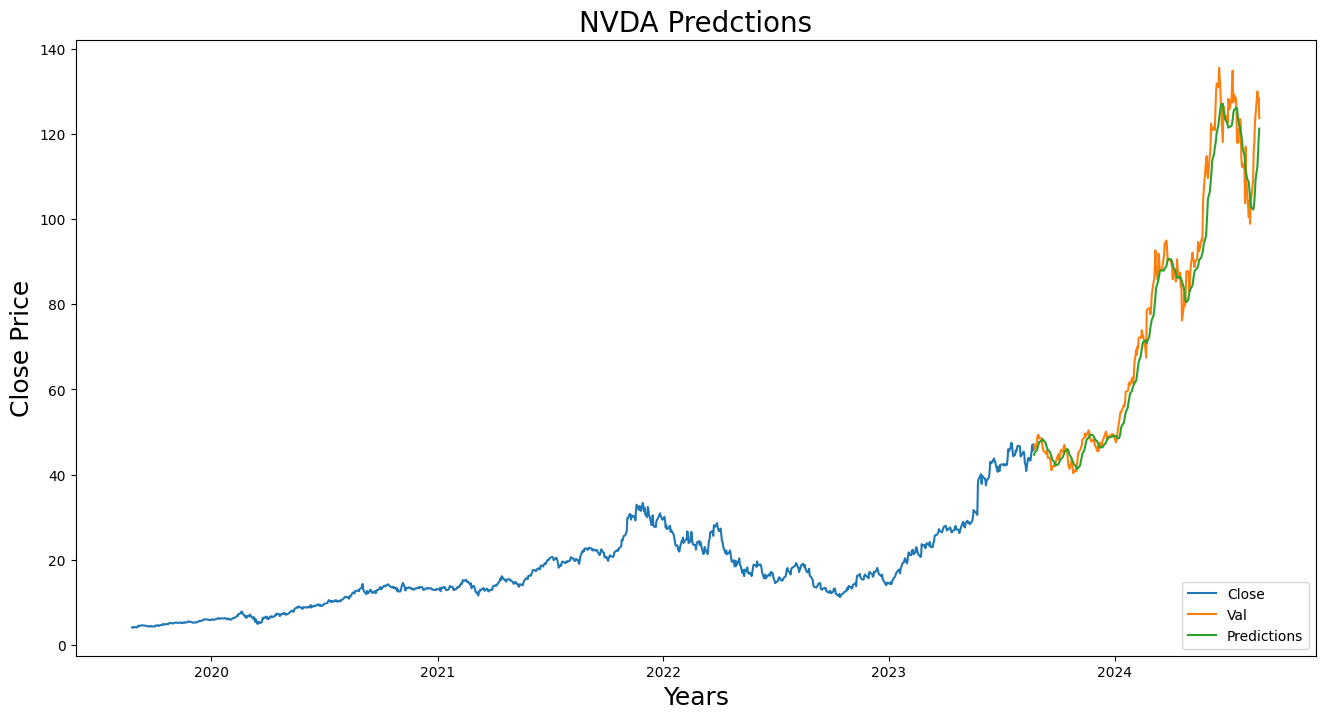

In [23]:
train = nvda[:training_data_len]
valid = nvda[training_data_len:]

valid.loc[:, 'Predictions'] = predictions

plt.figure(figsize=(16,8))
plt.title('NVDA Predctions', fontsize=20)
plt.xlabel('Years', fontsize=18)
plt.ylabel('Close Price', fontsize=18)


plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Close', 'Val', 'Predictions'], loc='lower right')

plt.savefig("NVDA_predictions_Validations.png")
plt.show()

In [24]:
valid.tail(60)

,Close,Predictions
Date,,
2024-05-29 00:00:00-04:00,114.815567,99.093979
2024-05-30 00:00:00-04:00,110.490921,102.334778
2024-05-31 00:00:00-04:00,109.624001,104.781609
2024-06-03 00:00:00-04:00,114.990555,106.448807
2024-06-04 00:00:00-04:00,116.427429,108.161530
2024-06-05 00:00:00-04:00,122.429947,109.812096
2024-06-06 00:00:00-04:00,120.988060,111.955505
2024-06-07 00:00:00-04:00,120.878075,113.865234
2024-06-10 00:00:00-04:00,121.779999,115.424919


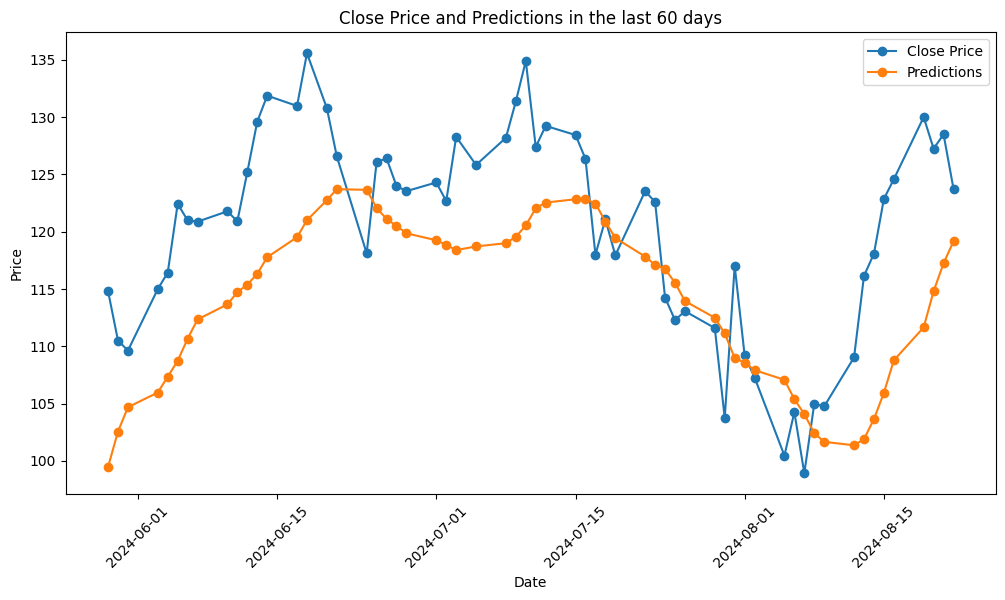

In [25]:
# Create a DataFrame from the data
data = {
    'Date': [
        '2024-05-29 00:00:00-04:00', '2024-05-30 00:00:00-04:00', '2024-05-31 00:00:00-04:00',
        '2024-06-03 00:00:00-04:00', '2024-06-04 00:00:00-04:00', '2024-06-05 00:00:00-04:00',
        '2024-06-06 00:00:00-04:00', '2024-06-07 00:00:00-04:00', '2024-06-10 00:00:00-04:00',
        '2024-06-11 00:00:00-04:00', '2024-06-12 00:00:00-04:00', '2024-06-13 00:00:00-04:00',
        '2024-06-14 00:00:00-04:00', '2024-06-17 00:00:00-04:00', '2024-06-18 00:00:00-04:00',
        '2024-06-20 00:00:00-04:00', '2024-06-21 00:00:00-04:00', '2024-06-24 00:00:00-04:00',
        '2024-06-25 00:00:00-04:00', '2024-06-26 00:00:00-04:00', '2024-06-27 00:00:00-04:00',
        '2024-06-28 00:00:00-04:00', '2024-07-01 00:00:00-04:00', '2024-07-02 00:00:00-04:00',
        '2024-07-03 00:00:00-04:00', '2024-07-05 00:00:00-04:00', '2024-07-08 00:00:00-04:00',
        '2024-07-09 00:00:00-04:00', '2024-07-10 00:00:00-04:00', '2024-07-11 00:00:00-04:00',
        '2024-07-12 00:00:00-04:00', '2024-07-15 00:00:00-04:00', '2024-07-16 00:00:00-04:00',
        '2024-07-17 00:00:00-04:00', '2024-07-18 00:00:00-04:00', '2024-07-19 00:00:00-04:00',
        '2024-07-22 00:00:00-04:00', '2024-07-23 00:00:00-04:00', '2024-07-24 00:00:00-04:00',
        '2024-07-25 00:00:00-04:00', '2024-07-26 00:00:00-04:00', '2024-07-29 00:00:00-04:00',
        '2024-07-30 00:00:00-04:00', '2024-07-31 00:00:00-04:00', '2024-08-01 00:00:00-04:00',
        '2024-08-02 00:00:00-04:00', '2024-08-05 00:00:00-04:00', '2024-08-06 00:00:00-04:00',
        '2024-08-07 00:00:00-04:00', '2024-08-08 00:00:00-04:00', '2024-08-09 00:00:00-04:00',
        '2024-08-12 00:00:00-04:00', '2024-08-13 00:00:00-04:00', '2024-08-14 00:00:00-04:00',
        '2024-08-15 00:00:00-04:00', '2024-08-16 00:00:00-04:00', '2024-08-19 00:00:00-04:00',
        '2024-08-20 00:00:00-04:00', '2024-08-21 00:00:00-04:00', '2024-08-22 00:00:00-04:00'
    ],
    'Close': [
        114.815567, 110.490921, 109.624001, 114.990555, 116.427429, 122.429947, 
        120.988060, 120.878075, 121.779999, 120.910004, 125.199997, 129.610001, 
        131.880005, 130.979996, 135.580002, 130.779999, 126.570000, 118.110001, 
        126.089996, 126.400002, 123.989998, 123.540001, 124.300003, 122.669998, 
        128.279999, 125.830002, 128.199997, 131.380005, 134.910004, 127.400002, 
        129.240005, 128.440002, 126.360001, 117.989998, 121.089996, 117.930000, 
        123.540001, 122.589996, 114.250000, 112.279999, 113.059998, 111.589996, 
        103.730003, 117.019997, 109.209999, 107.269997, 100.449997, 104.250000, 
        98.910004, 104.970001, 104.750000, 109.019997, 116.139999, 118.080002, 
        122.860001, 124.580002, 130.000000, 127.250000, 128.500000, 123.739998
    ],
    'Predictions': [
        99.458435, 102.551620, 104.677299, 105.956055, 107.345314, 108.721931, 
        110.658623, 112.339882, 113.654472, 114.717812, 115.382263, 116.319046, 
        117.774521, 119.515900, 121.003479, 122.753784, 123.710060, 123.657898, 
        122.081886, 121.108215, 120.508575, 119.861870, 119.252815, 118.852127, 
        118.393196, 118.714966, 118.995224, 119.551826, 120.548111, 122.035645, 
        122.546165, 122.832558, 122.843864, 122.461143, 120.886719, 119.446747, 
        117.828453, 117.110252, 116.746849, 115.544289, 113.940475, 112.488785, 
        111.117813, 108.976379, 108.567703, 107.914314, 107.066895, 105.377747, 
        104.077301, 102.415398, 101.652260, 101.350647, 101.880928, 103.635834, 
        105.930336, 108.768051, 111.642326, 114.806274, 117.241997, 119.161171
    ]
}

df = pd.DataFrame(data)
df['Date'] = pd.to_datetime(df['Date'])  # Convert Date column to datetime

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], marker='o', label='Close Price')
plt.plot(df['Date'], df['Predictions'], marker='o', label='Predictions')

plt.title('Close Price and Predictions in the last 60 days')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.xticks(rotation=45)

plt.savefig("NVDA_Close_and_Predictions.png")
plt.show()